In [1]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 0
METRICS_NOTES = "None"

UPDATE_DATABASE = False

LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

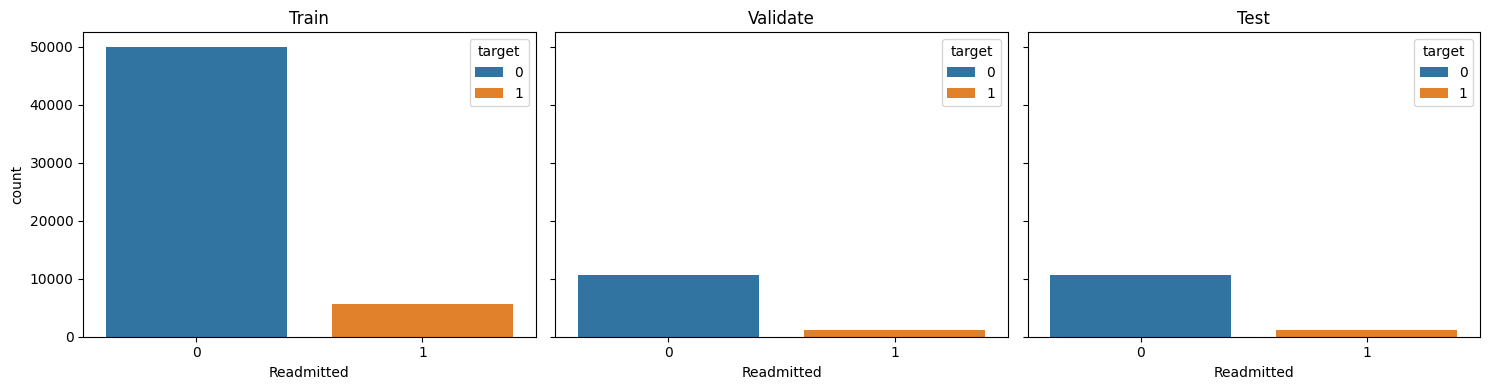

In [2]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scale=False,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [3]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.593 0.592 0.597 0.6   0.589]
mean roc_auc score: , 0.594
-----Undersample Baseline-----
roc_auc score per fold:  [0.654 0.635 0.624 0.653 0.632]
mean roc_auc score: , 0.640
Duration: 0 hrs, 0 mins, 18.1 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
6,number_inpatient,0.067331,0.007536
5,number_emergency,0.007000,0.001375
7,number_diagnoses,0.004328,0.002492
0,time_in_hospital,0.003697,0.001932
3,num_medications,0.003440,0.003609
2,num_procedures,0.002376,0.002096
15,diag1_group_respiratory,0.002362,0.001985
56,metformin_flag,0.002215,0.001492
37,specialty_cat_cardiology,0.002174,0.000552
58,num_drugs,0.002132,0.001904


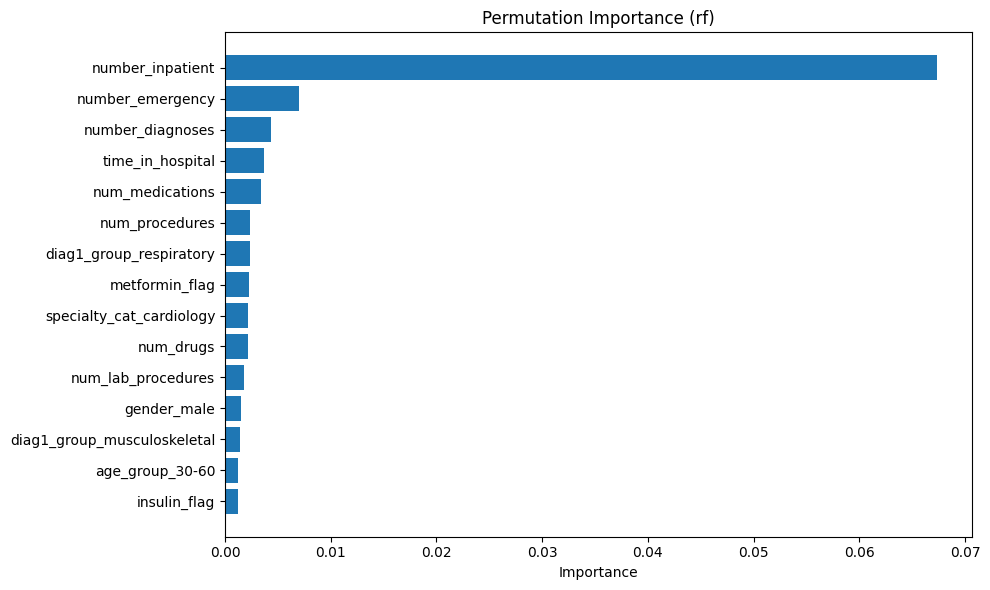

Duration: 0 hrs, 0 mins, 40.3 secs


In [4]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [6]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Best ROC_AUC (cv): 0.6582054064059548
Best params: {'model__oob_score': True, 'model__n_estimators': 200, 'model__min_samples_split': 15, 'model__min_samples_leaf': 6, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': None, 'model__bootstrap': True}
Duration: 0 hrs, 0 mins, 31.3 secs


In [7]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6388297144159754
Accuracy:      0.6400537860324397
F1 score:      0.23504197178067512
Precision:     0.14985196993851058
Recall:        0.5447019867549668

Confusion matrix:

TN: 6958, FP: 3733, FN: 550, TP: 658

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.76     10691
           1       0.15      0.54      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899



Best threshold (F2): 0.4079
Precision: 0.113  Recall: 0.912  F2: 0.379


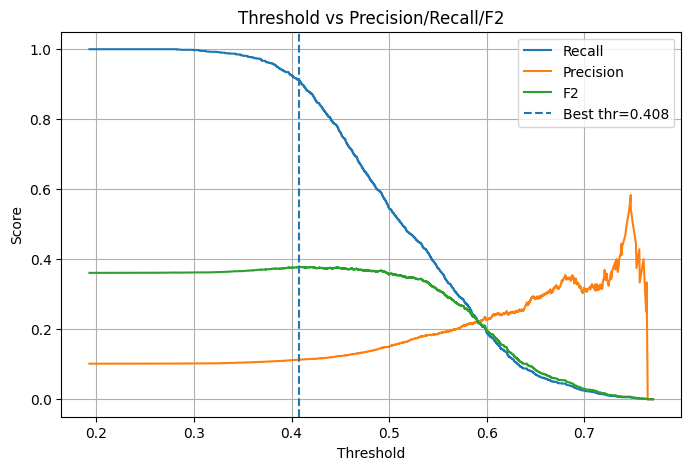

ROC_AUC:     0.6741033571432288
Accuracy:      0.27392516259819244
F1 score:      0.19723571161748227
Precision:     0.11049492518572773
Recall:        0.9174630755864466

Confusion matrix:

TN: 2187, FP: 8501, FN: 95, TP: 1056

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.20      0.34     10688
           1       0.11      0.92      0.20      1151

    accuracy                           0.27     11839
   macro avg       0.53      0.56      0.27     11839
weighted avg       0.88      0.27      0.32     11839



In [8]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

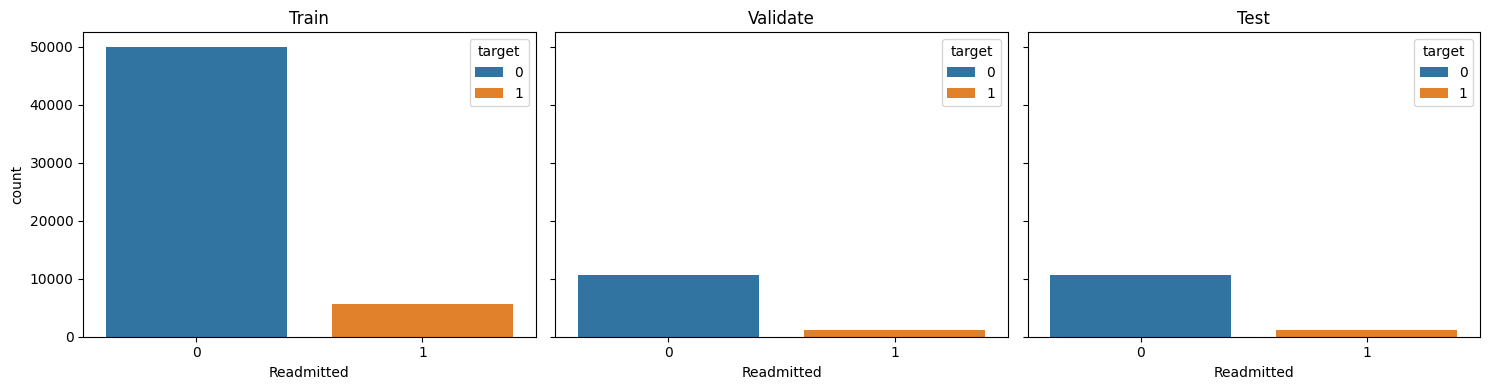

In [9]:
model = 'sgd' #SGDClassifier



sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scale=True,
)



,feature,importance_mean,importance_std
6,number_inpatient,0.054912,0.009091
5,number_emergency,0.006215,0.003694
0,time_in_hospital,0.005017,0.002086
7,number_diagnoses,0.003746,0.001124
12,diag1_group_musculoskeletal,0.003616,0.002483
3,num_medications,0.003269,0.001732
54,diabetesMed_flag,0.002115,0.000865
58,num_drugs,0.002097,0.000913
4,number_outpatient,0.001964,0.002594
73,i_hosp_time__specialty_cat_surgery,0.001521,0.001454


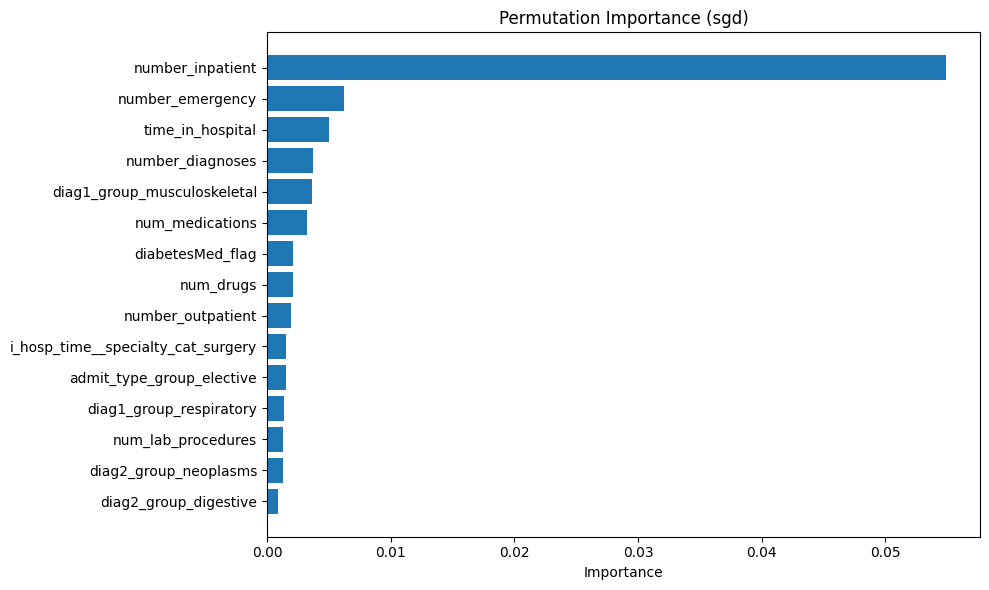

Duration: 0 hrs, 0 mins, 14.5 secs


In [10]:
sgd_pipe.permute_importance()

In [11]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.577 0.574 0.573 0.566 0.553]
mean roc_auc score: , 0.569
-----Undersample Baseline-----
roc_auc score per fold:  [0.612 0.596 0.607 0.585 0.548]
mean roc_auc score: , 0.590
Duration: 0 hrs, 0 mins, 11.7 secs


In [12]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Best ROC_AUC (cv): 0.6587578357191188
Best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}
Duration: 0 hrs, 0 mins, 40.9 secs


In [13]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6407767937505149
Accuracy:      0.6609799142785108
F1 score:      0.24001507159005275
Precision:     0.15536585365853658
Recall:        0.527317880794702

Confusion matrix:

TN: 7228, FP: 3463, FN: 571, TP: 637

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.16      0.53      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899



Best threshold (F2): 0.3888
Precision: 0.118  Recall: 0.859  F2: 0.381


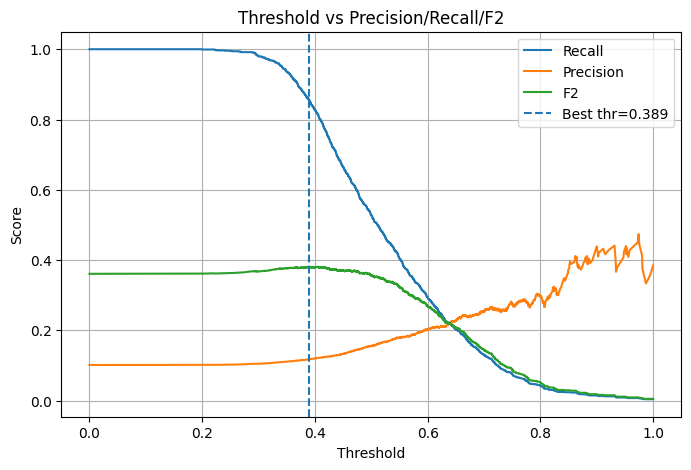

ROC_AUC:     0.6700535722646801
Accuracy:      0.34259650308303063
F1 score:      0.20182545379961028
Precision:     0.1144186046511628
Recall:        0.8549087749782798

Confusion matrix:

TN: 3072, FP: 7616, FN: 167, TP: 984

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.29      0.44     10688
           1       0.11      0.85      0.20      1151

    accuracy                           0.34     11839
   macro avg       0.53      0.57      0.32     11839
weighted avg       0.87      0.34      0.42     11839



In [14]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

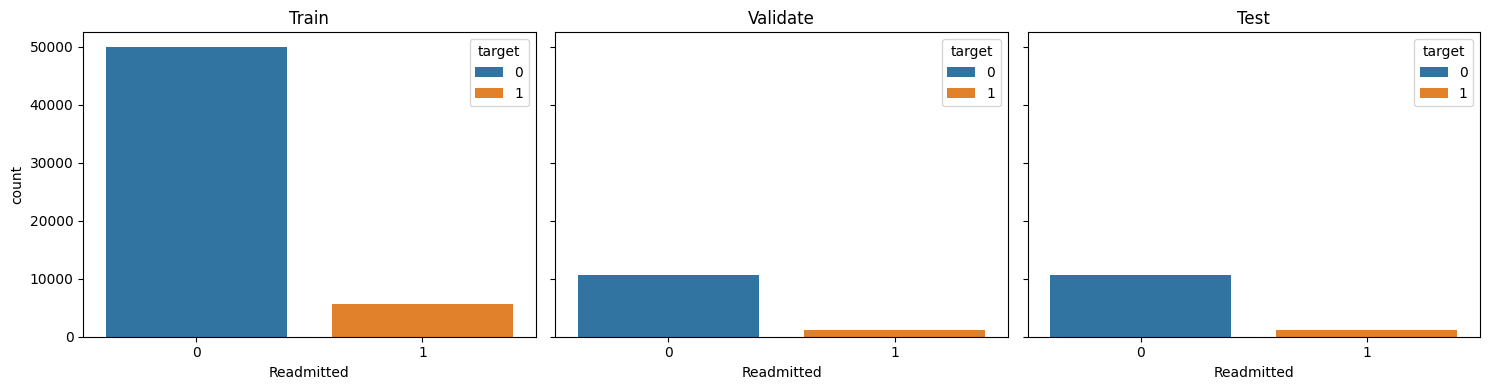

In [15]:
svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scale=True
)

In [16]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.636 0.644 0.661 0.638]
mean roc_auc score: , 0.644
Duration: 0 hrs, 0 mins, 15.1 secs


In [ ]:
# slow
# svc_pipe.permute_importance()

In [ ]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

In [ ]:
svc_pipe.validate()

In [ ]:
svc_pipe.test()

# XGBoost

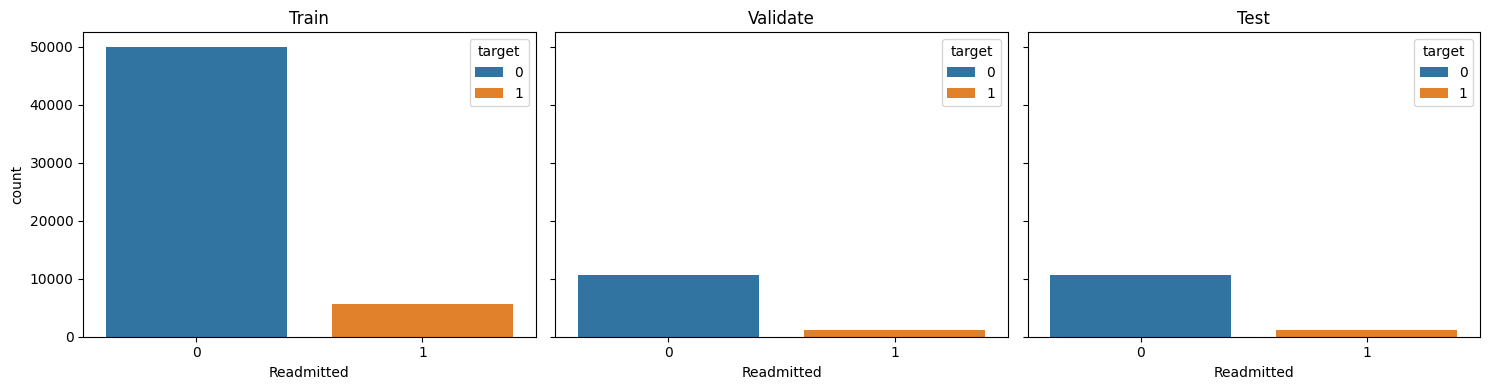

In [2]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=True,
    log_transform_cols=LOG_TRANSFORM_COLS
)

In [3]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.621 0.611 0.6   0.62  0.606]
mean roc_auc score: , 0.612
-----Undersample Baseline-----
roc_auc score per fold:  [0.622 0.62  0.618 0.634 0.623]
mean roc_auc score: , 0.623
Duration: 0 hrs, 0 mins, 14.3 secs


,feature,importance_mean,importance_std
6,number_inpatient,0.061919,0.008879
59,i_hosp_time__diag1_group_circulatory,0.006065,0.002787
3,num_medications,0.005486,0.001912
1,num_lab_procedures,0.005442,0.003084
5,number_emergency,0.004714,0.001979
7,number_diagnoses,0.003544,0.003497
2,num_procedures,0.002853,0.000878
57,insulin_flag,0.001739,0.001078
54,diabetesMed_flag,0.001651,0.000981
12,diag1_group_musculoskeletal,0.001651,0.000605


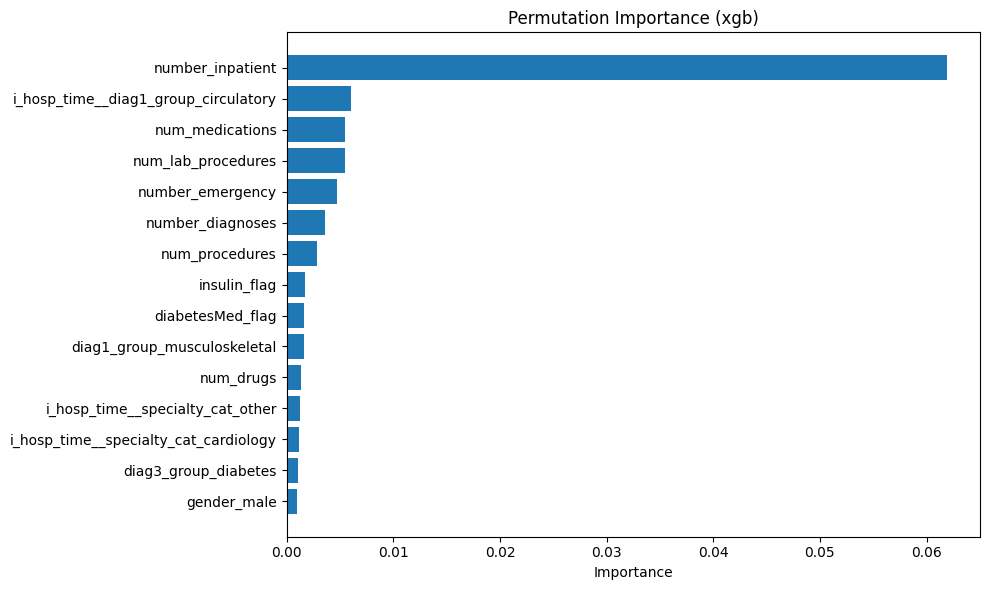

Duration: 0 hrs, 0 mins, 24.6 secs


In [19]:
xgb_pipe.permute_importance()

In [22]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(200, 1500),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': randint(2, 10),
    'model__min_child_weight': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': loguniform(max(approx_spw/5, 1e-3), approx_spw*5),
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Best ROC_AUC (cv): 0.653945324518924
Best params: {'model__colsample_bytree': np.float64(0.702254063561095), 'model__gamma': np.float64(4.438850493804799), 'model__learning_rate': np.float64(0.2567692501425787), 'model__max_depth': 2, 'model__min_child_weight': 8, 'model__n_estimators': 303, 'model__reg_alpha': np.float64(0.0001757937447736795), 'model__reg_lambda': np.float64(0.010655924993232578), 'model__scale_pos_weight': np.float64(2.4812758281839526), 'model__subsample': np.float64(0.8317508845540279)}
Duration: 0 hrs, 0 mins, 42.8 secs


In [23]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.636877176197594
Accuracy:      0.18925960164719724
F1 score:      0.19224650422841832
Precision:     0.10693991616208663
Recall:        0.9503311258278145

Confusion matrix:

TN: 1104, FP: 9587, FN: 60, TP: 1148

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.10      0.19     10691
           1       0.11      0.95      0.19      1208

    accuracy                           0.19     11899
   macro avg       0.53      0.53      0.19     11899
weighted avg       0.86      0.19      0.19     11899



Best threshold (F2): 0.6334
Precision: 0.126  Recall: 0.772  F2: 0.382


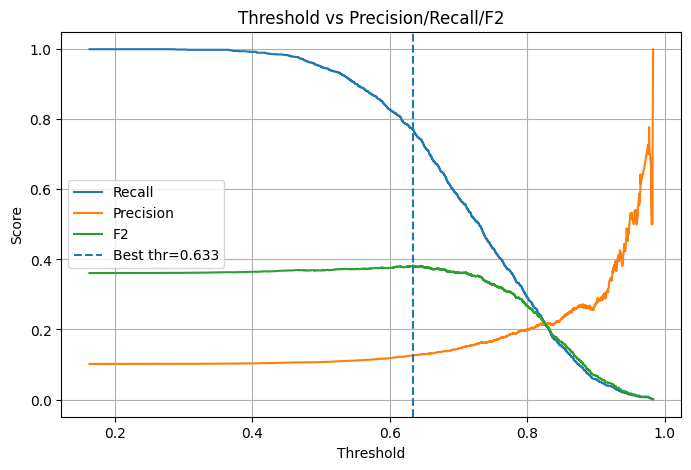

ROC_AUC:     0.6721681663822658
Accuracy:      0.44927781062589744
F1 score:      0.21803789877668506
Precision:     0.12647836371225823
Recall:        0.789748045178106

Confusion matrix:

TN: 4410, FP: 6278, FN: 242, TP: 909

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.41      0.57     10688
           1       0.13      0.79      0.22      1151

    accuracy                           0.45     11839
   macro avg       0.54      0.60      0.40     11839
weighted avg       0.87      0.45      0.54     11839



In [24]:
xgb_pipe.test()